# Lab 5: Intensity Transformation II - Histogram Processing

## Task 1: Histogram Equalization on Grayscale Image

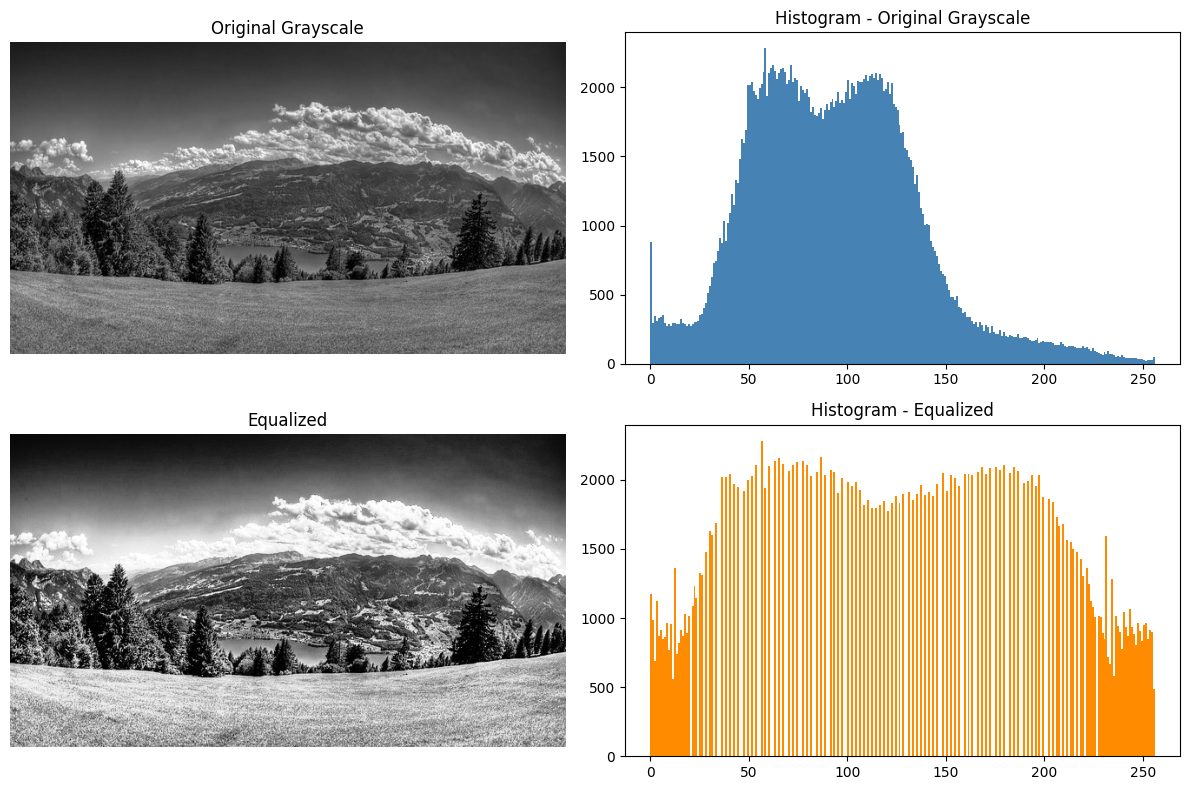

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_image(path, grayscale=True):
    if grayscale:
        return cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.imread(path)

def show_images_with_histograms(original, processed, title_original="Original", title_processed="Processed"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title(title_original)
    axes[0, 0].axis('off')
    
    axes[0, 1].hist(original.flatten(), bins=256, range=(0, 256), color='steelblue')
    axes[0, 1].set_title(f"Histogram - {title_original}")
    
    axes[1, 0].imshow(processed, cmap='gray')
    axes[1, 0].set_title(title_processed)
    axes[1, 0].axis('off')
    
    axes[1, 1].hist(processed.flatten(), bins=256, range=(0, 256), color='darkorange')
    axes[1, 1].set_title(f"Histogram - {title_processed}")
    
    plt.tight_layout()
    plt.show()

gray_img = load_image('nature.jpg', grayscale=True)
equalized_gray = cv2.equalizeHist(gray_img)
show_images_with_histograms(gray_img, equalized_gray, "Original Grayscale", "Equalized")

**Discussion:** Histogram equalization spreads the intensity values across the full range (0-255), which enhances contrast in images with poor lighting by making the histogram more uniform.

## Task 2: Histogram Equalization on Color Image

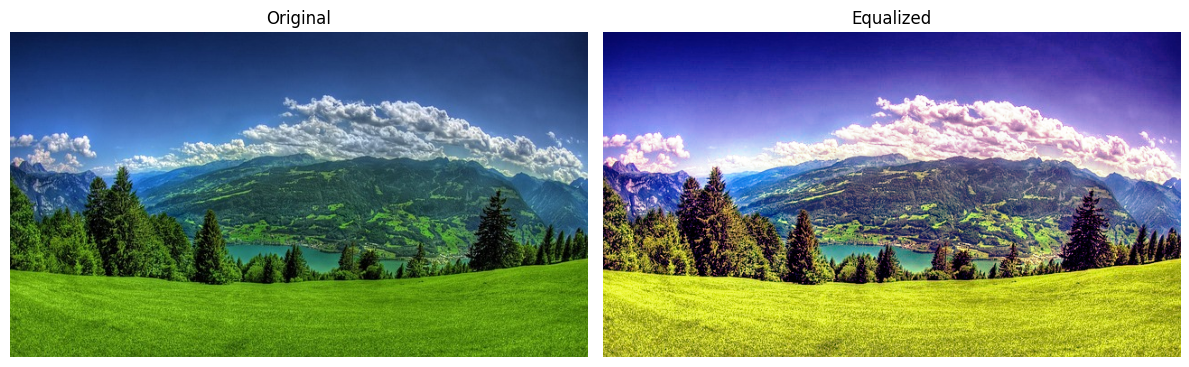

In [5]:
def equalize_color_channels(color_img):
    channels = cv2.split(color_img)
    equalized_channels = [cv2.equalizeHist(ch) for ch in channels]
    return cv2.merge(equalized_channels)

def display_color_comparison(orig, proc, titles=["Original", "Equalized"]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    proc_rgb = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)
    
    ax[0].imshow(orig_rgb)
    ax[0].set_title(titles[0])
    ax[0].axis('off')
    
    ax[1].imshow(proc_rgb)
    ax[1].set_title(titles[1])
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

color_img = load_image('nature.jpg', grayscale=False)
equalized_color = equalize_color_channels(color_img)
display_color_comparison(color_img, equalized_color)

**Observation:** Applying histogram equalization to each RGB channel separately can shift the color balance since each channel is treated independently.

## Task 3: Histogram Matching

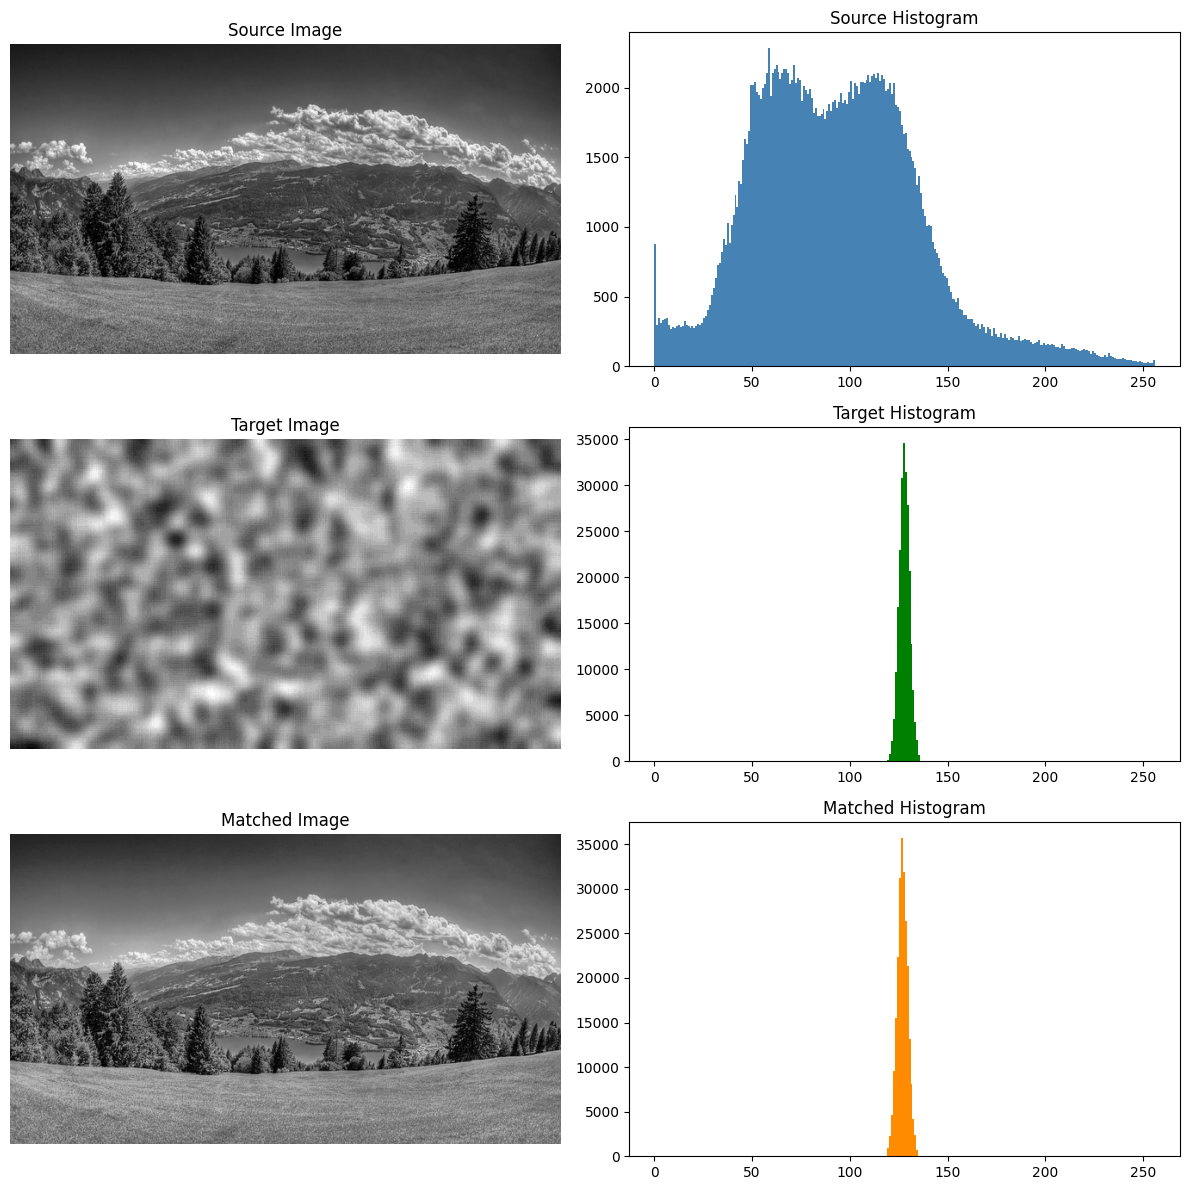

In [6]:
from skimage import exposure

def match_histogram(source, reference):
    return exposure.match_histograms(source, reference)

def show_matching_results(src, ref, matched):
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    
    axes[0, 0].imshow(src, cmap='gray')
    axes[0, 0].set_title('Source Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].hist(src.flatten(), bins=256, range=(0, 256), color='steelblue')
    axes[0, 1].set_title('Source Histogram')
    
    axes[1, 0].imshow(ref, cmap='gray')
    axes[1, 0].set_title('Target Image')
    axes[1, 0].axis('off')
    
    axes[1, 1].hist(ref.flatten(), bins=256, range=(0, 256), color='green')
    axes[1, 1].set_title('Target Histogram')
    
    axes[2, 0].imshow(matched, cmap='gray')
    axes[2, 0].set_title('Matched Image')
    axes[2, 0].axis('off')
    
    axes[2, 1].hist(matched.flatten(), bins=256, range=(0, 256), color='darkorange')
    axes[2, 1].set_title('Matched Histogram')
    
    plt.tight_layout()
    plt.show()

source_img = load_image('nature.jpg', grayscale=True)
target_img = np.random.randint(0, 256, source_img.shape, dtype=np.uint8)
target_img = cv2.GaussianBlur(target_img, (51, 51), 0)
matched_img = match_histogram(source_img, target_img)
show_matching_results(source_img, target_img, matched_img)

**Explanation:** Histogram matching transforms the source image's intensity distribution to match the target image's histogram, adjusting both brightness and contrast accordingly.

## Task 4: Combining Equalization and Matching

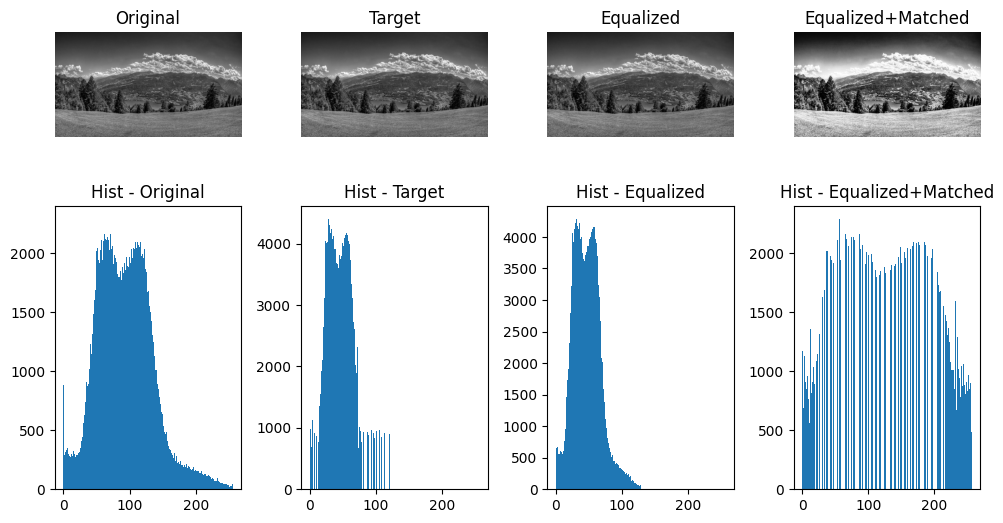

In [7]:
def pipeline_equalize_then_match(source, reference):
    equalized = cv2.equalizeHist(source)
    matched = match_histogram(equalized, reference)
    return equalized, matched

def display_pipeline_results(original, eq, matched, target):
    fig, axes = plt.subplots(2, 4, figsize=(10, 6))
    
    titles = ['Original', 'Target', 'Equalized', 'Equalized+Matched']
    images = [original, target, eq, matched]
    
    for i, (img, title) in enumerate(zip(images, titles)):
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(title)
        axes[0, i].axis('off')
        
        axes[1, i].hist(img.flatten(), bins=256, range=(0, 256))
        axes[1, i].set_title(f'Hist - {title}')
    
    plt.tight_layout()
    plt.show()

source_for_pipeline = load_image('nature.jpg', grayscale=True)
target_for_pipeline = load_image('nature.jpg', grayscale=True)
target_dark = np.clip(target_for_pipeline * 0.5, 0, 255).astype(np.uint8)
eq_img, combined_img = pipeline_equalize_then_match(source_for_pipeline, target_dark)
display_pipeline_results(source_for_pipeline, target_dark, eq_img, combined_img)

**summary:** Applying equalization first spreads the histogram, then matching it to a target allows us to control the final contrast distribution while still benefiting from the equalization's enhancement.